In [1]:
!pip install imbalanced-learn joblib

In [2]:
# # Fraud Detection Using Machine Learning

# ## Internship Project

# ### Project Objective

# The objective of this project is to develop a machine learning pipeline capable of identifying fraudulent financial transactions from a highly imbalanced dataset.

# The project includes data inspection, data cleaning, exploratory data analysis, feature engineering, class imbalance handling using SMOTE, model development, model evaluation, feature importance analysis and scalability discussion.

# ### Machine Learning Models

# 1. Logistic Regression
# 2. Random Forest

# ### Technologies Used

# - Python
# - pandas
# - NumPy
# - matplotlib
# - seaborn
# - scikit-learn
# - imbalanced-learn
# - Jupyter Notebook

Importing the required libraries

In [3]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

Loading the Datasets

In [4]:
transactions = pd.read_csv ("../data/paysim_transactions.csv")
customers = pd.read_csv ("../data/customers.csv")
fraud_cases = pd.read_csv("../data/fraud_cases.csv")
print("All datasets loaded successfully.")
                            

All datasets loaded successfully.



Datasets Inspections

In [5]:
display (transactions.head())
display (customers.head())
display (fraud_cases.head())

,transaction_id,customer_id,amount,timestamp,hour,day_of_week,location,merchant_category,is_new_device,device_id,ip_address,is_fraud,transaction_type,card_present
0,TX_00000000,CUST_005287,807.91,2026-08-29 11:13:27.372050,16,5,US,Food,False,DEV_4390,48.164.21.194,0,wire,True
1,TX_00000001,CUST_002180,734.39,2026-08-22 01:00:27.372684,7,4,UK,Retail,False,DEV_4068,212.254.99.120,0,online,False
2,TX_00000002,CUST_006491,2080.84,2026-08-22 04:53:27.372963,21,3,US,E-commerce,False,DEV_1115,137.60.196.229,0,in-store,False
3,TX_00000003,CUST_008714,2521.49,2026-09-02 18:32:27.373252,21,3,UK,E-commerce,False,DEV_2305,119.126.69.84,0,atm,True
4,TX_00000004,CUST_004620,1802.67,2026-08-30 00:06:27.373504,10,4,IN,Food,False,DEV_4547,60.246.141.253,0,wire,False


,customer_id,segment,account_age_days,risk_score,email_verified,phone_verified,avg_monthly_transactions,avg_transaction_amount,device_count,location
0,CUST_000000,Retail,2332,0.697657,True,True,45,2064.757168,3,US
1,CUST_000001,Retail,531,0.588541,True,True,83,3040.637196,4,IN
2,CUST_000002,Business,1974,0.364320,True,True,9,2079.751870,1,US
3,CUST_000003,Retail,1852,0.454465,True,True,94,1135.531920,3,IN
4,CUST_000004,Business,2185,0.631022,False,True,94,3991.774005,2,IN


,case_id,transaction_id,customer_id,fraud_amount,detection_time,fraud_type,status,investigator
0,FC_000021,TX_00000021,CUST_007238,134960.11,2026-08-06 06:31:27.377676,Suspicious Pattern,Under Review,INV_018
1,FC_000040,TX_00000040,CUST_005511,35381.62,2026-08-20 20:06:27.382354,Suspicious Pattern,Under Review,INV_013
2,FC_000122,TX_00000122,CUST_001316,28093.77,2026-08-19 01:25:27.401235,Location Mismatch,Under Review,NaN
3,FC_000128,TX_00000128,CUST_003935,194942.10,2026-09-01 09:40:27.402620,Device Anomaly,Confirmed,NaN
4,FC_000130,TX_00000130,CUST_002237,25678.05,2026-08-19 20:23:27.403100,Velocity,False Positive,INV_019


Dataset Dimensions

In [6]:
print("Transactions shape:", transactions.shape)
print ("Customers shape:", customers.shape)
print ("Fraud Cases shape:", fraud_cases.shape)

Transactions shape: (100000, 14)
Customers shape: (10000, 10)
Fraud Cases shape: (1955, 8)


Information of the Datasets

In [7]:
print ("TRANSACTION DATA")
transactions.info()

print ("\nCUSTOMER DATA")
customers.info()

print ("\nFRAUD CASE DATA")
fraud_cases.info()

TRANSACTION DATA
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   transaction_id     100000 non-null  str    
 1   customer_id        100000 non-null  str    
 2   amount             100000 non-null  float64
 3   timestamp          100000 non-null  str    
 4   hour               100000 non-null  int64  
 5   day_of_week        100000 non-null  int64  
 6   location           100000 non-null  str    
 7   merchant_category  100000 non-null  str    
 8   is_new_device      100000 non-null  bool   
 9   device_id          100000 non-null  str    
 10  ip_address         100000 non-null  str    
 11  is_fraud           100000 non-null  int64  
 12  transaction_type   100000 non-null  str    
 13  card_present       100000 non-null  bool   
dtypes: bool(2), float64(1), int64(3), str(8)
memory usage: 17.4 MB

CUSTOMER DATA
<class 'pandas.Da

Missing Values

In [8]:
print("Transaction missing values:")
display(transactions.isnull().sum())

print("Customer missing values:")
display(customers.isnull().sum())

print("Fraud case missing values:")
display(fraud_cases.isnull().sum())

Transaction missing values:


transaction_id       0
customer_id          0
amount               0
timestamp            0
hour                 0
day_of_week          0
location             0
merchant_category    0
is_new_device        0
device_id            0
ip_address           0
is_fraud             0
transaction_type     0
card_present         0
dtype: int64

Customer missing values:


customer_id                 0
segment                     0
account_age_days            0
risk_score                  0
email_verified              0
phone_verified              0
avg_monthly_transactions    0
avg_transaction_amount      0
device_count                0
location                    0
dtype: int64

Fraud case missing values:


case_id             0
transaction_id      0
customer_id         0
fraud_amount        0
detection_time      0
fraud_type          0
status              0
investigator      956
dtype: int64

Duplicate rows & Identifiers

In [9]:
print (
    "Transaction duplicates:",
    transactions.duplicated().sum()
)

print (
    "Customer duplicates:",
    customers.duplicated().sum()
)

print (
    "Fraud case duplicates:",
    fraud_cases.duplicated().sum()
)

Transaction duplicates: 0
Customer duplicates: 0
Fraud case duplicates: 0


In [10]:
print(
    "Duplicate transaction IDs:",
    transactions["transaction_id"].duplicated().sum()
)

print(
    "Duplicate customer IDs:",
    customers["customer_id"].duplicated().sum()
)

print(
    "Duplicate case IDs:",
    fraud_cases["case_id"].duplicated().sum()
)

Duplicate transaction IDs: 0
Duplicate customer IDs: 0
Duplicate case IDs: 0


Converting Dates and Times

In [11]:
transactions["timestamp"] = pd.to_datetime(
    transactions["timestamp"],
    errors="coerce"
)

fraud_cases["detection_time"] = pd.to_datetime(
    fraud_cases["detection_time"],
    errors="coerce"
)

print("Invalid transaction timestamps:")
print(transactions["timestamp"].isnull().sum())

print("Invalid detection timestamps:")
print(fraud_cases["detection_time"].isnull().sum())

Invalid transaction timestamps:
0
Invalid detection timestamps:
0


In [12]:
transactions["transaction_hour"] = (
    transactions["timestamp"].dt.hour
)

transactions["transaction_day"] = (
    transactions["timestamp"].dt.day
)

transactions["transaction_month"] = (
    transactions["timestamp"].dt.month
)

transactions["transaction_weekday"] = (
    transactions["timestamp"].dt.dayofweek    #days of week value 0-6=monday-sunday
)

transactions["is_weekend"] = (
    transactions["transaction_weekday"]
    .isin([5, 6])
    .astype(int)
)

transactions = transactions.dropna(
    subset=["timestamp"]
).copy()


Joining transactions with customer information

In [13]:
customers_for_merge = customers.rename(
    columns={"location": "customer_location"}
)

#Merge Datasets
df = transactions.merge(
    customers_for_merge,
    on="customer_id",
    how="left",
    validate="many_to_one"
)

print("Merged dataset shape:", df.shape)
df.head()

Merged dataset shape: (100000, 28)


,transaction_id,customer_id,amount,timestamp,hour,day_of_week,location,merchant_category,is_new_device,device_id,ip_address,is_fraud,transaction_type,card_present,transaction_hour,transaction_day,transaction_month,transaction_weekday,is_weekend,segment,account_age_days,risk_score,email_verified,phone_verified,avg_monthly_transactions,avg_transaction_amount,device_count,customer_location
0,TX_00000000,CUST_005287,807.91,2026-08-29 11:13:27.372050,16,5,US,Food,False,DEV_4390,48.164.21.194,0,wire,True,11,29,8,5,1,Retail,1394,0.520467,True,True,52,799.728774,3,US
1,TX_00000001,CUST_002180,734.39,2026-08-22 01:00:27.372684,7,4,UK,Retail,False,DEV_4068,212.254.99.120,0,online,False,1,22,8,5,1,Retail,256,0.592291,True,True,51,1358.790483,3,UK
2,TX_00000002,CUST_006491,2080.84,2026-08-22 04:53:27.372963,21,3,US,E-commerce,False,DEV_1115,137.60.196.229,0,in-store,False,4,22,8,5,1,Business,968,0.512422,True,True,75,1543.891662,3,US
3,TX_00000003,CUST_008714,2521.49,2026-09-02 18:32:27.373252,21,3,UK,E-commerce,False,DEV_2305,119.126.69.84,0,atm,True,18,2,9,2,0,Retail,2621,0.451517,False,False,8,2417.631163,1,UK
4,TX_00000004,CUST_004620,1802.67,2026-08-30 00:06:27.373504,10,4,IN,Food,False,DEV_4547,60.246.141.253,0,wire,False,0,30,8,6,1,Retail,2281,0.452063,False,True,56,3872.284181,4,IN


In [14]:
#checking merged matching customer information in the merged data
customer_columns = [
    "segment",
    "account_age_days",
    "risk_score",
    "customer_location"
]

print(df[customer_columns].isnull().sum())

segment              0
account_age_days     0
risk_score           0
customer_location    0
dtype: int64


Creating Safe Features for Location mismatch, Log transaction amount, Amount compared with customer average, Convert Boolean columns

In [15]:
#location mismatch
df["location_mismatch"] = (
    df["location"] != df["customer_location"]
).astype(int)

In [16]:
#Log transaction amount
df["amount_log"] = np.log1p(df["amount"])

In [17]:
#Amount compared with customer average
df["amount_ratio_to_customer_avg"] = (
    df["amount"]
    / df["avg_transaction_amount"].replace(0, np.nan)
)

df["amount_ratio_to_customer_avg"] = (
    df["amount_ratio_to_customer_avg"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

In [18]:
#Convert Boolean columns
boolean_columns = [
    "is_new_device",
    "card_present",
    "email_verified",
    "phone_verified"
]

for column in boolean_columns:
    df[column] = df[column].astype(int)

Descriptive Analysis

In [19]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
transaction_id,100000,100000,TX_00000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,100000,9999,CUST_004027,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,100000.0,NaN,NaN,NaN,3471.33026,5.01,704.245,1935.96,3964.315,199815.75,10342.948363
timestamp,100000,NaN,NaN,NaN,2026-08-18 21:43:00.616582,2026-08-03 20:59:32.104402,2026-08-11 10:09:38.089635,2026-08-18 21:45:30.334481,2026-08-26 09:26:28.364880,2026-09-02 20:58:48.987421,NaN
hour,100000.0,NaN,NaN,NaN,13.46788,0.0,9.0,13.0,18.0,23.0,4.679024
day_of_week,100000.0,NaN,NaN,NaN,3.002,0.0,1.0,3.0,5.0,6.0,2.001029
location,100000,9,US,38867,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_category,100000,6,Services,16722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_new_device,100000.0,NaN,NaN,NaN,0.00597,0.0,0.0,0.0,0.0,1.0,0.077035
device_id,100000,4999,DEV_0774,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
#Numerical statistics by class
df.groupby("is_fraud")[
    ["amount", "risk_score", "account_age_days"]
].agg([
    "count", 
    "mean", 
    "median",
    "std",
    "min",
    "max"
]).round(2)

amount                                                  risk_score  \
          count      mean    median       std     min        max      count   
is_fraud                                                                      
0         98045   2503.66   1874.77   2195.71    5.01    9935.39      98045   
1          1955  52001.06  30708.85  53192.69  507.56  199815.75       1955   

                                      account_age_days                   \
          mean median   std  min  max            count     mean  median   
is_fraud                                                                  
0         0.50   0.50  0.16  0.0  1.0            98045  1824.84  1819.0   
1         0.49   0.49  0.15  0.0  1.0             1955  1877.31  1893.0   

                             
              std min   max  
is_fraud                     
0         1042.38  30  3649  
1         1047.53  30  3647

Analyze class imbalance

In [21]:
#Fraud Counts
class_counts = (
    df["is_fraud"]
    .value_counts()
    .sort_index()
)

non_fraud_count = class_counts[0]
fraud_count = class_counts[1]
fraud_percentage = fraud_count / len(df) * 100

print("Total transactions:", len(df))
print("Non-fraud transactions:", non_fraud_count)
print("Fraudulent transactions:", fraud_count)
print(f"Fraud percentage: {fraud_percentage:.3f}%")

Total transactions: 100000
Non-fraud transactions: 98045
Fraudulent transactions: 1955
Fraud percentage: 1.955%


C:\Users\kusma\AppData\Local\Temp\ipykernel_21356\1196816158.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


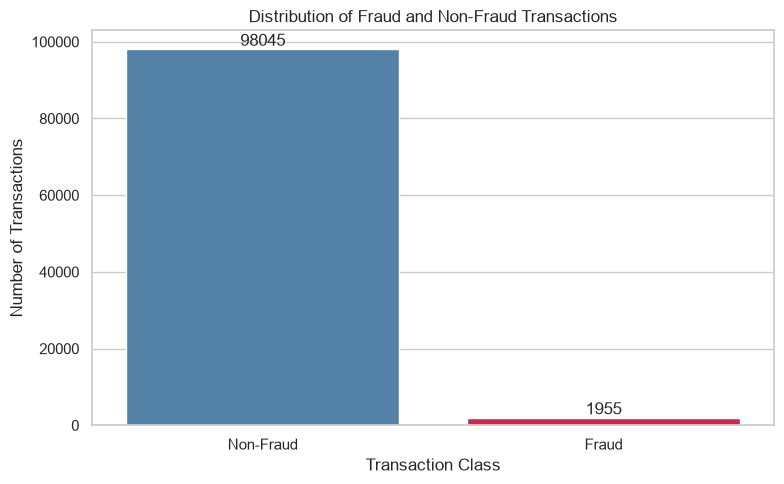

In [22]:
#Class distribution chart
class_plot_data = (
    df["is_fraud"]
    .map({0: "Non-Fraud", 1: "Fraud"})
)

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    x=class_plot_data,
    order=["Non-Fraud", "Fraud"],
    palette=["steelblue", "crimson"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Distribution of Fraud and Non-Fraud Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

Class Imbalance Analysis

The dataset contains 100,000 transactions, of which only 1,955 are fraudulent. Fraud therefore represents approximately 1.955% of all transactions.

This demonstrates a serious class imbalance. A model that predicts every observation as non-fraud would achieve approximately 98.045% accuracy but would detect none of the fraudulent transactions. Therefore, accuracy cannot be treated as the primary evaluation metric.

In [23]:
#EDA 1: Transaction amount by class
amount_summary = df.groupby("is_fraud")["amount"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

amount_summary.index = ["Non-Fraud", "Fraud"]
amount_summary.round(2)

,count,mean,median,std,min,max
Non-Fraud,98045,2503.66,1874.77,2195.71,5.01,9935.39
Fraud,1955,52001.06,30708.85,53192.69,507.56,199815.75


C:\Users\kusma\AppData\Local\Temp\ipykernel_21356\3011346150.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


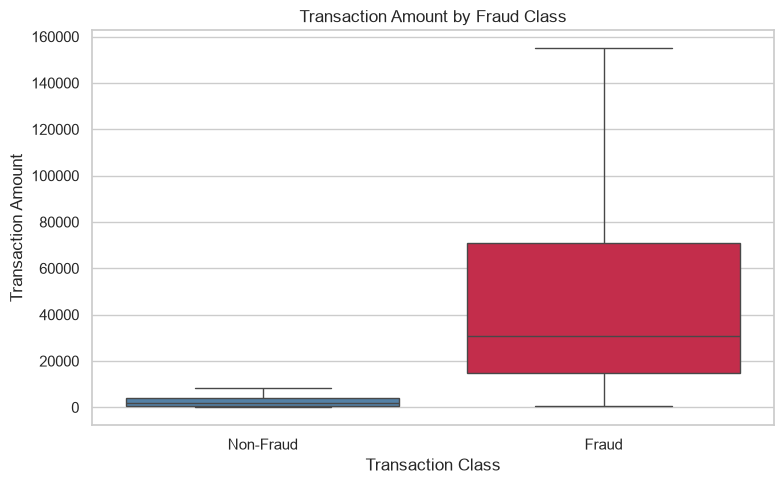

In [24]:
#Box Plot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="amount",
    showfliers=False,
    palette=["steelblue", "crimson"]
)

plt.xticks([0, 1], ["Non-Fraud", "Fraud"])
plt.title("Transaction Amount by Fraud Class")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")
plt.tight_layout()
plt.show()

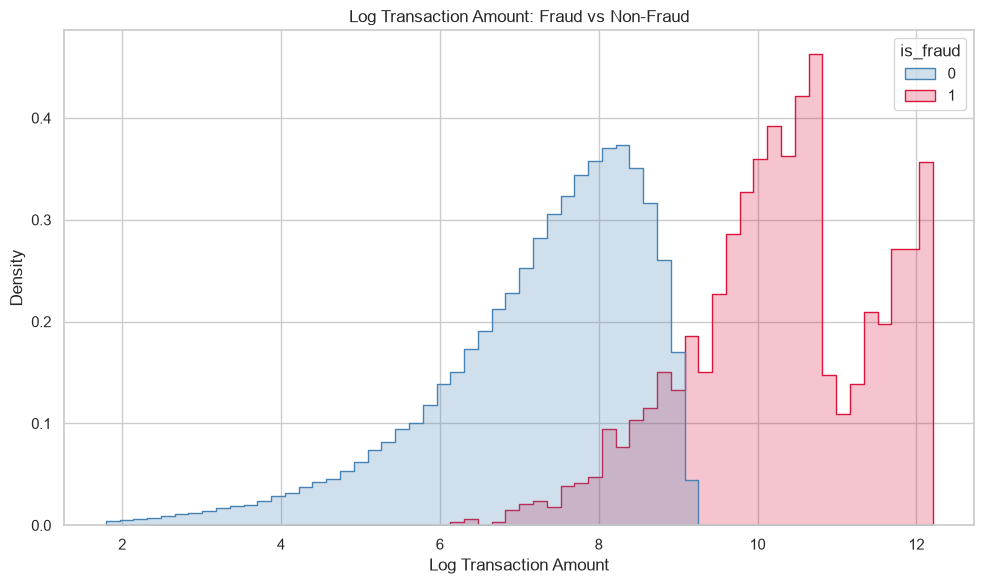

In [25]:
#Log amount distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="amount_log",
    hue="is_fraud",
    bins=60,
    stat="density",
    common_norm=False,
    element="step",
    palette={0: "steelblue", 1: "crimson"}
)

plt.title("Log Transaction Amount: Fraud vs Non-Fraud")
plt.xlabel("Log Transaction Amount")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

Fraudulent transactions have substantially higher transaction amounts than legitimate transactions. The log transformation makes the heavily skewed amount distributions easier to compare.

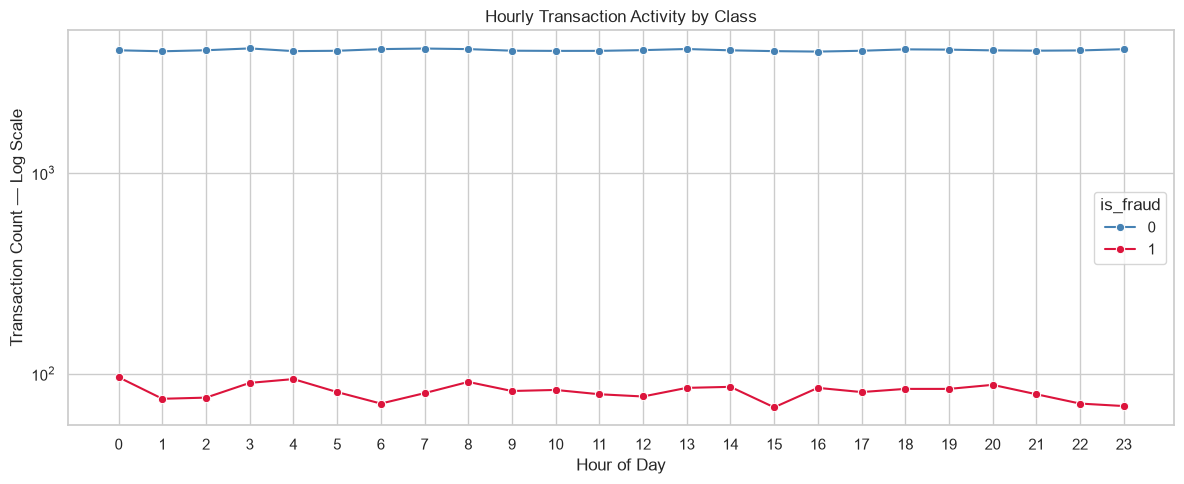

In [26]:
#EDA 2: Time-of-day analysis > Transaction counts by hour
hourly_class = (
    df.groupby(["transaction_hour", "is_fraud"])
    .size()
    .reset_index(name="transaction_count")
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_class,
    x="transaction_hour",
    y="transaction_count",
    hue="is_fraud",
    marker="o",
    palette={0: "steelblue", 1: "crimson"}
)

plt.yscale("log")
plt.xticks(range(24))
plt.title("Hourly Transaction Activity by Class")
plt.xlabel("Hour of Day")
plt.ylabel("Transaction Count — Log Scale")
plt.tight_layout()
plt.show()

In [27]:
#Fraud rate by hour
hourly_fraud = df.groupby(
    "transaction_hour"
)["is_fraud"].agg(
    total_transactions="count",
    fraud_transactions="sum"
)

hourly_fraud["fraud_rate"] = (
    hourly_fraud["fraud_transactions"]
    / hourly_fraud["total_transactions"]
    * 100
)

hourly_fraud = hourly_fraud.reset_index()
hourly_fraud

,transaction_hour,total_transactions,fraud_transactions,fraud_rate
0,0,4175,96,2.299401
1,1,4108,75,1.825706
2,2,4157,76,1.828242
3,3,4258,90,2.113668
4,4,4135,94,2.273277
5,5,4137,81,1.957941
6,6,4206,71,1.688065
7,7,4242,80,1.885903
8,8,4226,91,2.153336
9,9,4142,82,1.979720


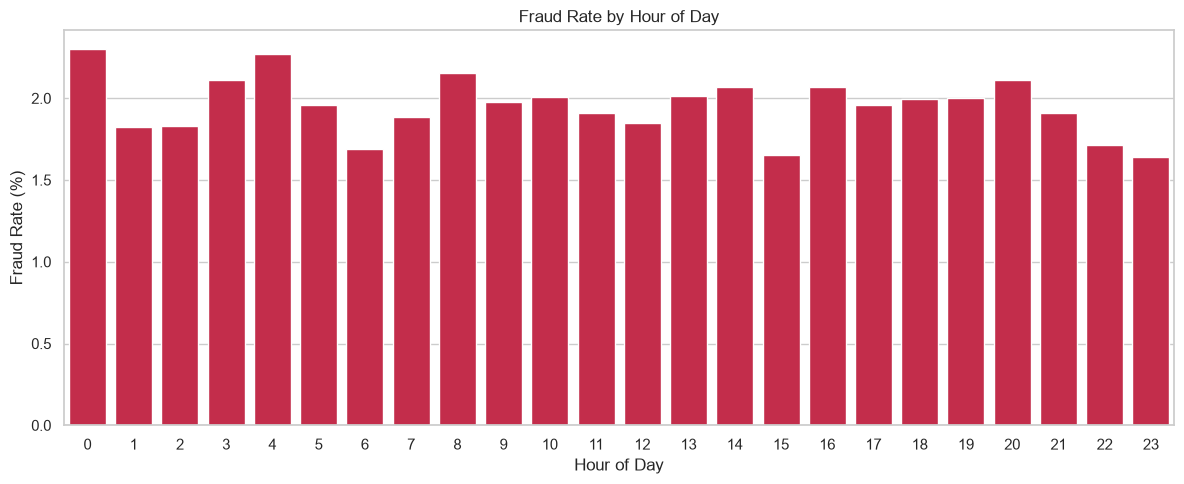

In [28]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=hourly_fraud,
    x="transaction_hour",
    y="fraud_rate",
    color="crimson"
)

plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

Fraud rate is more meaningful than fraud count because it considers the total number of transactions occurring each hour.

In [29]:
#EDA 3: Fraud by transaction type
type_fraud = df.groupby(
    "transaction_type"
)["is_fraud"].agg(
    total_transactions="count",
    fraud_transactions="sum"
)

type_fraud["fraud_rate"] = (
    type_fraud["fraud_transactions"]
    / type_fraud["total_transactions"]
    * 100
)

type_fraud = (
    type_fraud
    .reset_index()
    .sort_values("fraud_rate", ascending=False)
)

type_fraud

,transaction_type,total_transactions,fraud_transactions,fraud_rate
2,online,24886,541,2.173913
0,atm,25040,501,2.000799
1,in-store,24924,457,1.833574
3,wire,25150,456,1.813121


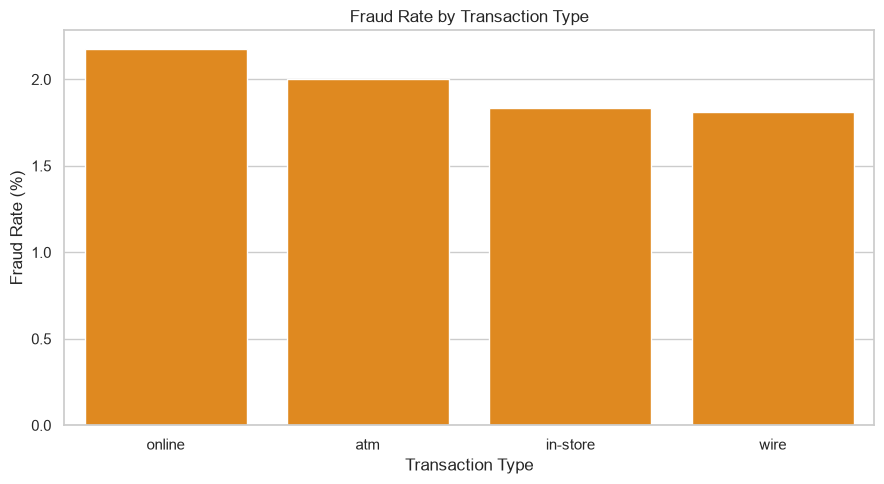

In [30]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=type_fraud,
    x="transaction_type",
    y="fraud_rate",
    color="darkorange"
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

In [31]:
#EDA 4: New device and fraud
device_fraud = pd.crosstab(
    df["is_new_device"],
    df["is_fraud"],
    normalize="index"
) * 100

device_fraud.columns = ["Non-Fraud (%)", "Fraud (%)"]
device_fraud.index = ["Known Device", "New Device"]
device_fraud.round(2)

,Non-Fraud (%),Fraud (%)
Known Device,98.63,1.37
New Device,0.00,100.00


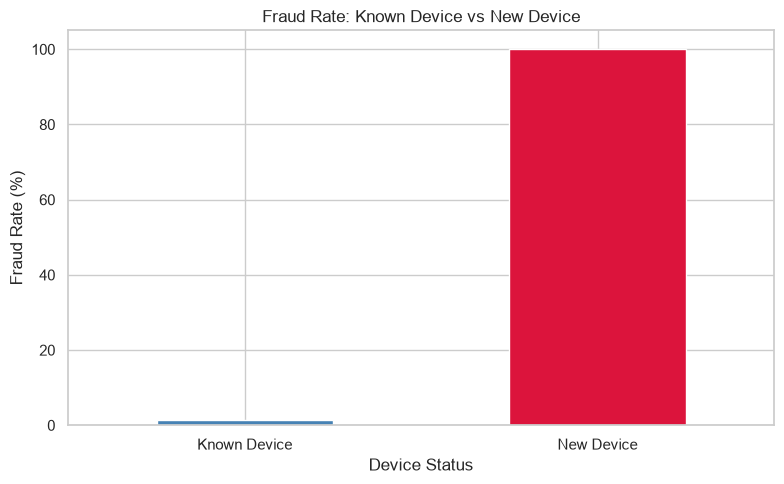

In [32]:
device_fraud["Fraud (%)"].plot(
    kind="bar",
    figsize=(8, 5),
    color=["steelblue", "crimson"]
)

plt.title("Fraud Rate: Known Device vs New Device")
plt.xlabel("Device Status")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
#EDA 5: Location mismatch
location_fraud = pd.crosstab(
    df["location_mismatch"],
    df["is_fraud"],
    normalize="index"
) * 100

location_fraud.columns = ["Non-Fraud (%)", "Fraud (%)"]
location_fraud.index = [
    "Location Matched",
    "Location Mismatched"
]

location_fraud.round(2)

,Non-Fraud (%),Fraud (%)
Location Matched,98.42,1.58
Location Mismatched,0.00,100.00


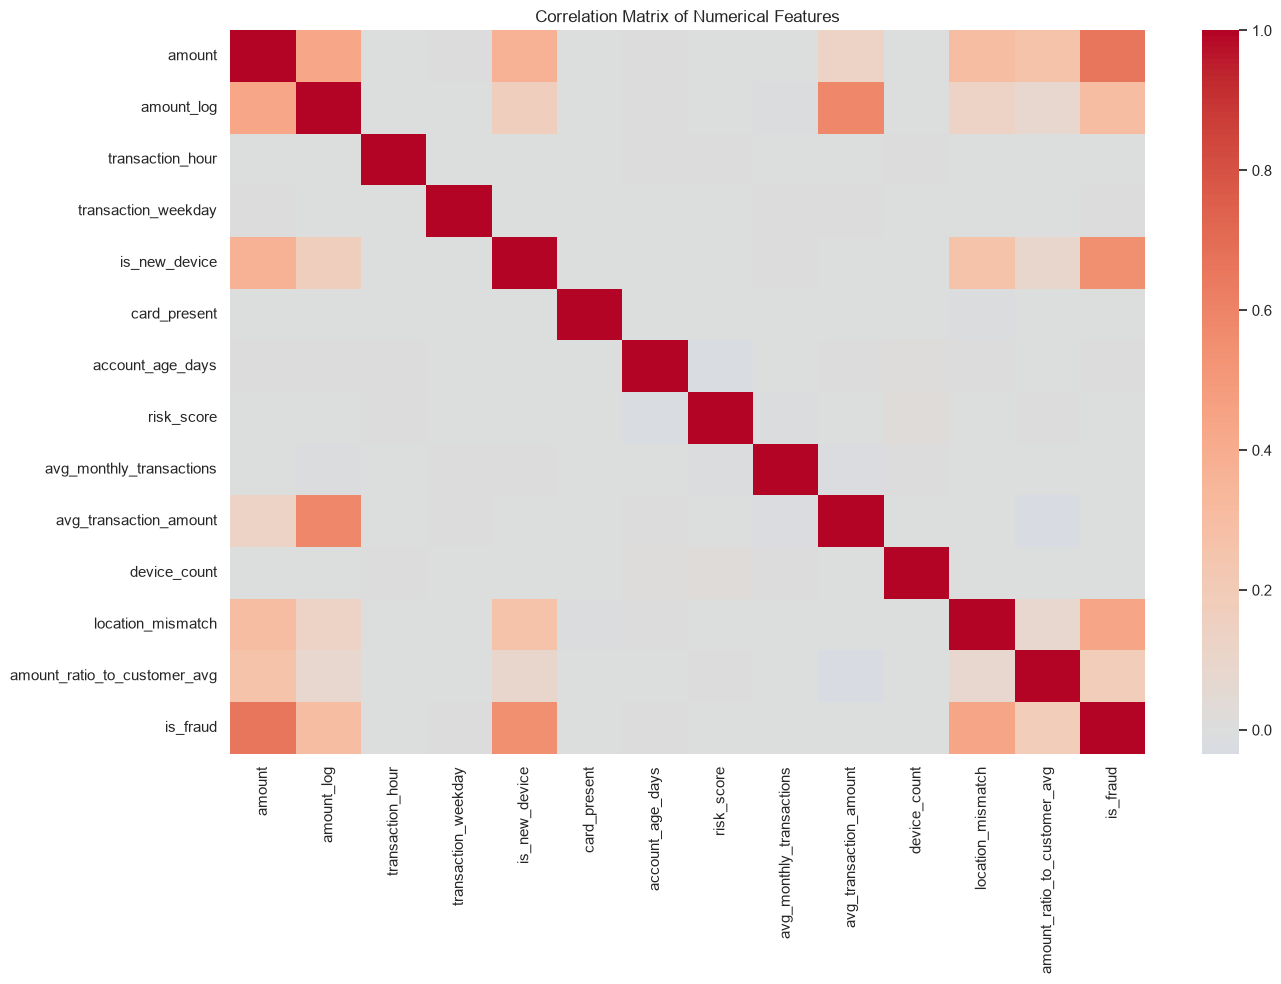

In [34]:
#EDA 6: Correlation heatmap
correlation_columns = [
    "amount",
    "amount_log",
    "transaction_hour",
    "transaction_weekday",
    "is_new_device",
    "card_present",
    "account_age_days",
    "risk_score",
    "avg_monthly_transactions",
    "avg_transaction_amount",
    "device_count",
    "location_mismatch",
    "amount_ratio_to_customer_avg",
    "is_fraud"
]

correlation_matrix = (
    df[correlation_columns]
    .corr(numeric_only=True)
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

Why Standard Accuracy Is Misleading? 

Accuracy calculates the percentage of all predictions that are correct. It may be misleading when one class is much larger than the other.

In this project, 98.045% of transactions are non-fraud. A model could classify every transaction as non-fraud and still obtain 98.045% accuracy. However, its fraud recall would be 0% because it would fail to detect every fraudulent transaction.

For this reason, precision, recall, F1-score, confusion matrix, ROC-AUC and Precision-Recall AUC are more appropriate evaluation measures.

In [35]:
numerical_features = [
    "amount_log",
    "transaction_hour",
    "transaction_day",
    "transaction_month",
    "transaction_weekday",
    "is_weekend",
    "is_new_device",
    "card_present",
    "account_age_days",
    "risk_score",
    "email_verified",
    "phone_verified",
    "avg_monthly_transactions",
    "avg_transaction_amount",
    "device_count",
    "location_mismatch",
    "amount_ratio_to_customer_avg"
]

categorical_features = [
    "location",
    "merchant_category",
    "transaction_type",
    "segment",
    "customer_location"
]

feature_columns = (
    numerical_features
    + categorical_features
)

X = df[feature_columns].copy()
y = df["is_fraud"].copy()

print("Feature data shape:", X.shape)
print("Target shape:", y.shape)
#We use amount_log instead of both amount and amount_log to reduce duplication.

Feature data shape: (100000, 22)
Target shape: (100000,)


In [36]:
#the train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

print(
    "\nTraining fraud percentage:",
    round(y_train.mean() * 100, 3)
)

print(
    "Testing fraud percentage:",
    round(y_test.mean() * 100, 3)
)

Training set: (80000, 22)
Testing set: (20000, 22)

Training target:
is_fraud
0    78436
1     1564
Name: count, dtype: int64

Testing target:
is_fraud
0    19609
1      391
Name: count, dtype: int64

Training fraud percentage: 1.955
Testing fraud percentage: 1.955


In [37]:
#the preprocessing system > the preprocessing system
numerical_transformer = SklearnPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [39]:
#Categorical preprocessing
categorical_transformer = SklearnPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [40]:
#Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

In [41]:
#Build Model 1 — Logistic Regression
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "smote",
            SMOTE(
                sampling_strategy=0.25,
                random_state=RANDOM_STATE
            )
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

In [42]:
#Train logistic regression
logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [43]:
#Build Model 2 — Random Forest
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "smote",
            SMOTE(
                sampling_strategy=0.25,
                random_state=RANDOM_STATE
            )
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=150,
                max_depth=12,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [44]:
#Train Random Forest 
random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [45]:
#Generate Predictions
models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline
}

predictions = {}
probabilities = {}

for model_name, model in models.items():
    predictions[model_name] = model.predict(X_test)

    probabilities[model_name] = (
        model.predict_proba(X_test)[:, 1]
    )

print("Predictions generated successfully.")

Predictions generated successfully.


In [46]:
#Evaluate the model > evaluation function
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_probability
):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )
    roc_auc = roc_auc_score(
        y_true,
        y_probability
    )
    pr_auc = average_precision_score(
        y_true,
        y_probability
    )

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}")

    print("\nClassification Report:")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "Non-Fraud",
                "Fraud"
            ],
            zero_division=0
        )
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }

In [47]:
#Evaluate of both models
model_results = []

for model_name in models:
    result = evaluate_model(
        model_name,
        y_test,
        predictions[model_name],
        probabilities[model_name]
    )

    model_results.append(result)

Logistic Regression
Accuracy:  0.9984
Precision: 1.0000
Recall:    0.9207
F1-Score:  0.9587
ROC-AUC:   0.9799
PR-AUC:    0.9432

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     19609
       Fraud       1.00      0.92      0.96       391

    accuracy                           1.00     20000
   macro avg       1.00      0.96      0.98     20000
weighted avg       1.00      1.00      1.00     20000

Random Forest
Accuracy:  0.9988
Precision: 1.0000
Recall:    0.9386
F1-Score:  0.9683
ROC-AUC:   0.9788
PR-AUC:    0.9468

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     19609
       Fraud       1.00      0.94      0.97       391

    accuracy                           1.00     20000
   macro avg       1.00      0.97      0.98     20000
weighted avg       1.00      1.00      1.00     20000



In [48]:
#Model comparison table
results_df = pd.DataFrame(model_results)

results_df = (
    results_df
    .set_index("Model")
    .round(4)
)

results_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
Logistic Regression,0.9984,1.0,0.9207,0.9587,0.9799,0.9432
Random Forest,0.9988,1.0,0.9386,0.9683,0.9788,0.9468


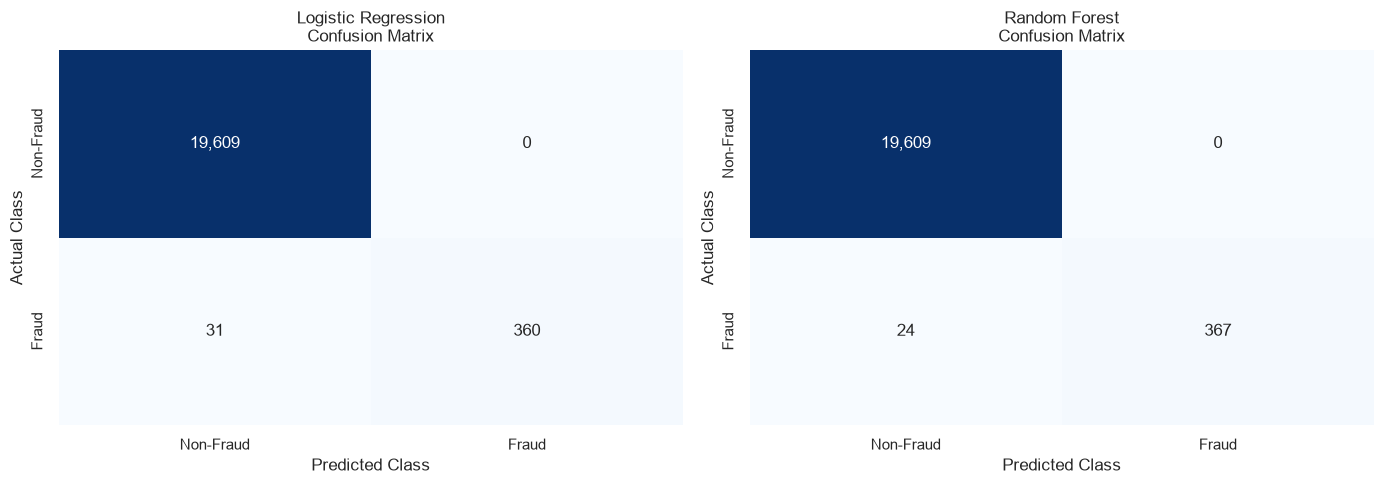

In [49]:
#Plot confusion matrixes
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

for ax, model_name in zip(
    axes,
    models.keys()
):
    cm = confusion_matrix(
        y_test,
        predictions[model_name]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt=",",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(
        f"{model_name}\nConfusion Matrix"
    )
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

    ax.set_xticklabels([
        "Non-Fraud",
        "Fraud"
    ])

    ax.set_yticklabels([
        "Non-Fraud",
        "Fraud"
    ])

plt.tight_layout()
plt.show()

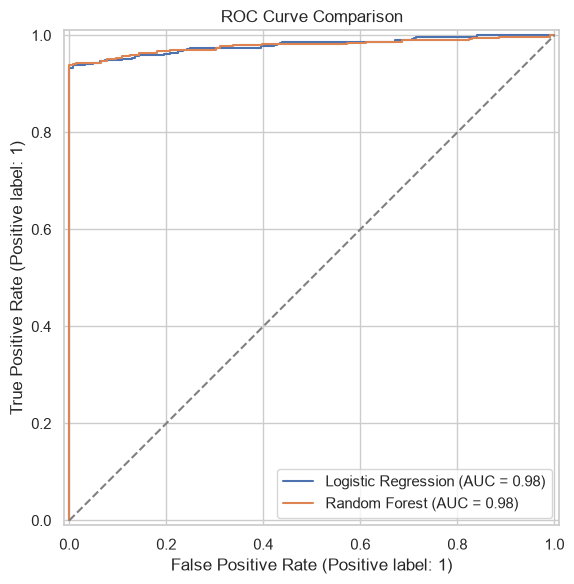

In [50]:
#Plot ROC curves
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, model in models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=model_name,
        ax=ax
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

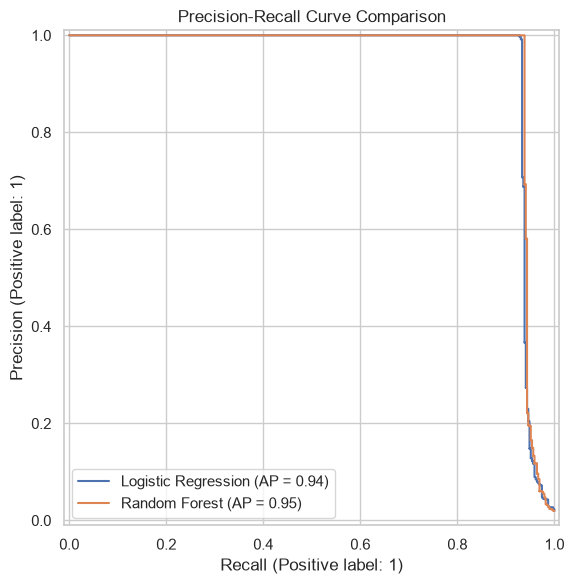

In [51]:
#Plot Precision-Recall curves
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, model in models.items():
    PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=model_name,
        ax=ax
    )

plt.title("Precision-Recall Curve Comparison")
plt.tight_layout()
plt.show()

## Model Evaluation Metrics

### Precision

Precision represents the proportion of transactions predicted as fraud that were actually fraudulent.

High precision means that fraud alerts are usually correct. Low precision means the system produces many false alerts.

### Recall

Recall represents the percentage of all actual fraud cases detected by the model.

High recall means fewer fraudulent transactions are missed. Low recall means that many fraudulent transactions are incorrectly approved.

### F1-Score

F1-score balances precision and recall. It is useful when both false negatives and false positives are important.

### ROC-AUC

ROC-AUC measures the model's ability to rank fraudulent transactions above legitimate transactions across different classification thresholds.

### Precision-Recall AUC

PR-AUC summarizes the relationship between precision and recall. It is especially useful for heavily imbalanced datasets.

## Which Metric Matters Most?

Recall is generally the first priority in fraud detection because a false negative means that an actual fraudulent transaction was not detected. This may result in direct financial loss.

However, focusing entirely on recall could generate too many false-positive alerts. False alerts increase investigation costs and may inconvenience legitimate customers.

The final model should therefore provide high recall while maintaining acceptable precision. F1-score helps compare this balance, while the final threshold should be selected according to the cost of missed fraud and false alerts.

In [52]:
#Feature importance analysis > Retrieve feature names
fitted_preprocessor = (
    random_forest_pipeline
    .named_steps["preprocessor"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

feature_names = [
    name.replace("numerical__", "")
        .replace("categorical__", "")
    for name in feature_names
]

print("Number of model features:", len(feature_names))

Number of model features: 45


In [53]:
#Random Forest feature importance
rf_model = (
    random_forest_pipeline
    .named_steps["model"]
)

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

rf_top_features = (
    rf_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .head(15)
)

rf_top_features

,feature,importance
16,amount_ratio_to_customer_avg,0.443312
0,amount_log,0.326887
6,is_new_device,0.061584
15,location_mismatch,0.029969
34,transaction_type_online,0.012592
35,transaction_type_wire,0.011083
19,location_CN,0.010745
18,location_BR,0.010579
38,segment_Retail,0.009379
33,transaction_type_in-store,0.007103


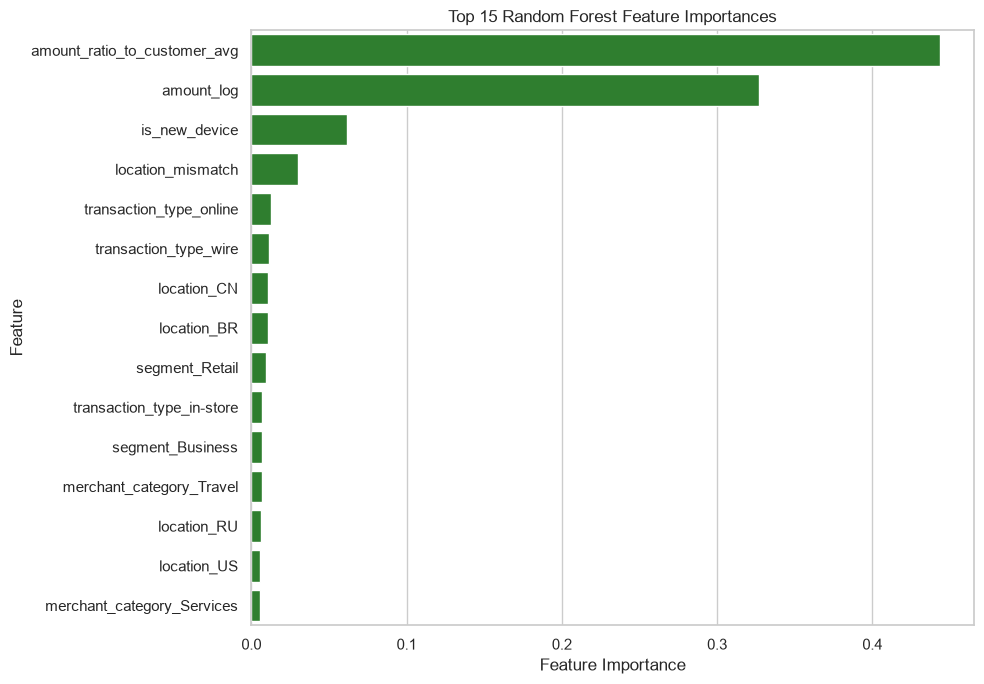

In [54]:
#Plot Importance
plt.figure(figsize=(10, 7))

sns.barplot(
    data=rf_top_features,
    x="importance",
    y="feature",
    color="forestgreen"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [55]:
#Logistic Regression coefficients
logistic_model = (
    logistic_pipeline
    .named_steps["model"]
)

coefficient_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": logistic_model.coef_[0]
})

coefficient_df["absolute_coefficient"] = (
    coefficient_df["coefficient"].abs()
)

top_coefficients = (
    coefficient_df
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .head(15)
)

top_coefficients

,feature,coefficient,absolute_coefficient
16,amount_ratio_to_customer_avg,15.725701,15.725701
0,amount_log,7.048134,7.048134
13,avg_transaction_amount,-2.269054,2.269054
6,is_new_device,1.237800,1.237800
15,location_mismatch,0.876279,0.876279
32,transaction_type_atm,-0.767017,0.767017
37,segment_Premium,-0.754949,0.754949
35,transaction_type_wire,-0.749985,0.749985
36,segment_Business,-0.582427,0.582427
20,location_IN,-0.566519,0.566519


C:\Users\kusma\AppData\Local\Temp\ipykernel_21356\963335718.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


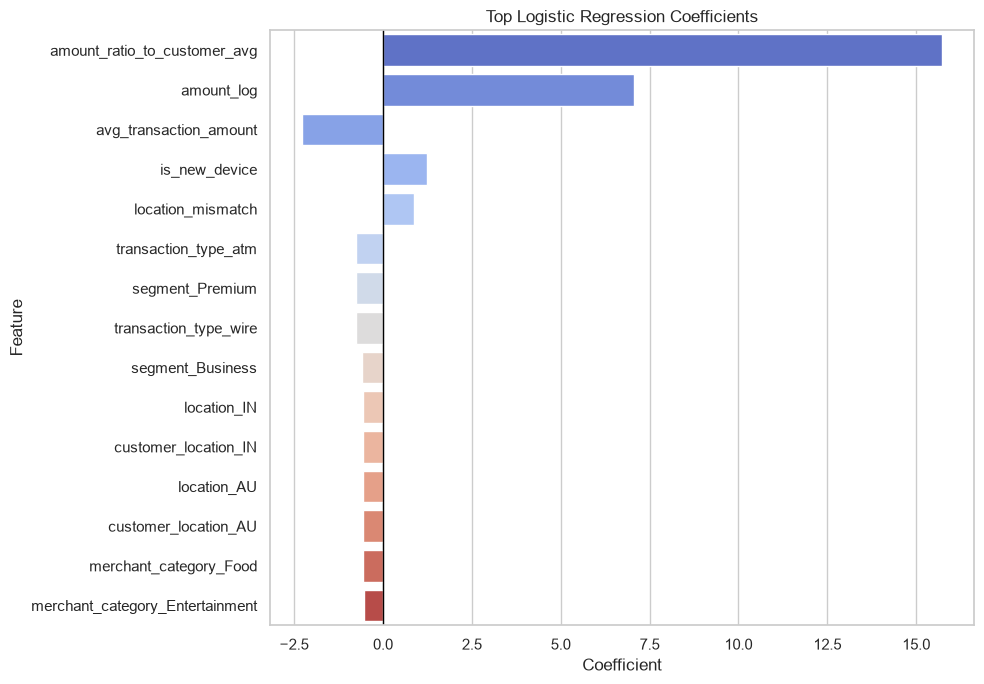

In [56]:
#Plot coefficients
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_coefficients,
    x="coefficient",
    y="feature",
    palette="coolwarm"
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [58]:
#Compare classification thresholds
selected_model_name = "Random Forest"

selected_probabilities = (
    probabilities[selected_model_name]
)

threshold_results = []

for threshold in [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70
]:
    threshold_predictions = (
        selected_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            threshold_predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1-Score
0,0.1,0.991892,0.938619,0.964520
1,0.2,1.000000,0.938619,0.968338
2,0.3,1.000000,0.938619,0.968338
3,0.4,1.000000,0.938619,0.968338
4,0.5,1.000000,0.938619,0.968338
5,0.6,1.000000,0.938619,0.968338
6,0.7,1.000000,0.925831,0.961487


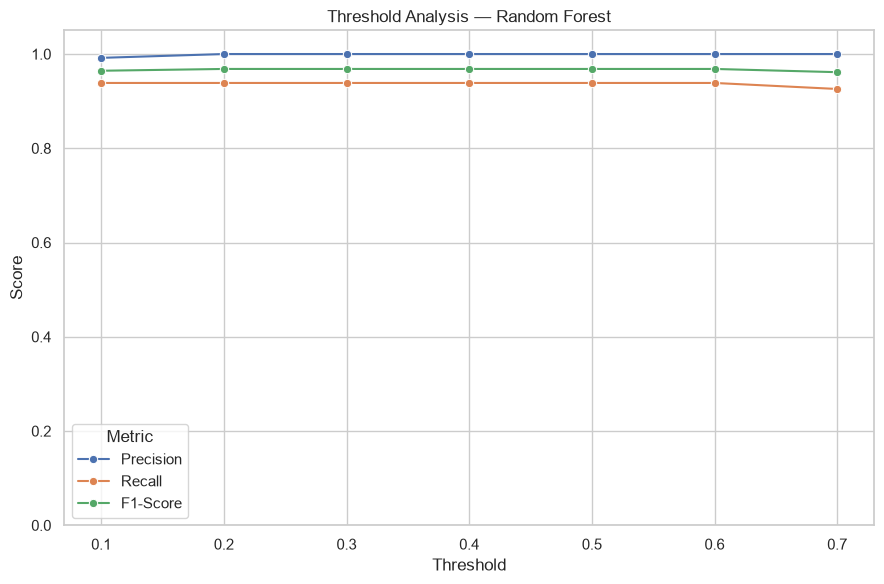

In [59]:
#Threshold chart
threshold_long = threshold_df.melt(
    id_vars="Threshold",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9, 6))

sns.lineplot(
    data=threshold_long,
    x="Threshold",
    y="Score",
    hue="Metric",
    marker="o"
)

plt.title(
    f"Threshold Analysis — {selected_model_name}"
)

plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [60]:
#Displaying the final comparison
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        0.99845,
        0.99880
    ],
    "Precision": [
        1.0000,
        1.0000
    ],
    "Recall": [
        0.9207,
        0.9386
    ],
    "F1-Score": [
        0.9587,
        0.9683
    ],
    "ROC-AUC": [
        0.9799,
        0.9788
    ],
    "PR-AUC": [
        0.9432,
        0.9468
    ],
    "Fraud Detected": [
        360,
        367
    ],
    "Fraud Missed": [
        31,
        24
    ],
    "False Positives": [
        0,
        0
    ]
})

final_comparison.set_index("Model")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Fraud Detected,Fraud Missed,False Positives
Model,,,,,,,,,
Logistic Regression,0.99845,1.0,0.9207,0.9587,0.9799,0.9432,360,31,0
Random Forest,0.99880,1.0,0.9386,0.9683,0.9788,0.9468,367,24,0


In [61]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    random_forest_pipeline,
    "../models/fraud_detection_model.joblib"
)

print("Final model saved successfully.")

Final model saved successfully.


In [62]:
os.makedirs("../outputs", exist_ok=True)

results_df.to_csv(
    "../outputs/model_comparison.csv"
)

rf_top_features.to_csv(
    "../outputs/feature_importance.csv",
    index=False
)

threshold_df.to_csv(
    "../outputs/threshold_analysis.csv",
    index=False
)

In [63]:
#Testing the Saved Model
loaded_model = joblib.load(
    "../models/fraud_detection_model.joblib"
)

sample_transactions = X_test.head(5)

sample_predictions = loaded_model.predict(
    sample_transactions
)

sample_probabilities = loaded_model.predict_proba(
    sample_transactions
)[:, 1]

sample_results = sample_transactions.copy()

sample_results["actual_class"] = (
    y_test.head(5).values
)

sample_results["predicted_class"] = (
    sample_predictions
)

sample_results["fraud_probability"] = (
    sample_probabilities
)

sample_results

,amount_log,transaction_hour,transaction_day,transaction_month,transaction_weekday,is_weekend,is_new_device,card_present,account_age_days,risk_score,email_verified,phone_verified,avg_monthly_transactions,avg_transaction_amount,device_count,location_mismatch,amount_ratio_to_customer_avg,location,merchant_category,transaction_type,segment,customer_location,actual_class,predicted_class,fraud_probability
9864,7.253251,7,23,8,6,1,0,0,3025,0.439106,0,1,77,1489.506152,4,0,0.947757,IN,Services,wire,Business,IN,0,0,0.001555
16528,6.485490,21,10,8,0,0,0,1,667,0.491024,1,1,52,406.579101,1,0,1.609920,US,Travel,atm,Business,US,0,0,0.004901
82036,8.334872,12,16,8,6,1,0,1,233,0.424325,1,1,22,3073.676308,1,0,1.355273,SG,Entertainment,wire,Business,SG,0,0,0.006341
95254,7.638087,17,15,8,5,1,0,1,1442,0.482608,1,0,13,3864.574316,2,0,0.536869,UK,Travel,online,Student,UK,0,0,0.007517
57438,6.369147,19,23,8,6,1,0,1,3413,0.394218,1,1,45,4941.877927,4,0,0.117882,AU,Travel,online,Student,AU,0,0,0.009961


## Scalability: One Million Transactions per Hour

One million transactions per hour is approximately 278 transactions per second. A production system would require a scalable real-time architecture rather than a local Jupyter Notebook.

### Real-Time Data Ingestion

Transactions could enter the system through Apache Kafka, Amazon Kinesis or Google Pub/Sub.

### Fast Feature Processing

Features required for fraud prediction should be calculated using optimized streaming transformations. Customer history, registered location and device information could be retrieved from a low-latency feature store.

### Model Serving

The trained pipeline could be deployed through an API. Logistic Regression is computationally inexpensive and suitable for fast predictions. Random Forest can also provide fast predictions if the number and depth of trees are controlled.

### Parallel Processing

Transactions could be distributed among multiple model-serving instances. Apache Spark or Flink could process high-volume data streams in parallel.

### Two-Stage Detection

A fast model could first score every transaction. Transactions with high-risk scores could be blocked or passed to a more advanced model. Medium-risk transactions could require additional verification.

### Monitoring

The production system should monitor:

- Fraud recall
- Precision
- False-positive rate
- Prediction speed
- Feature drift
- Data drift
- Changes in fraud behaviour

### Model Retraining

Fraud techniques change over time. The model should be regularly evaluated and retrained using recently confirmed fraud cases.

### Security

Customer and payment information should be encrypted, access controlled and processed according to applicable financial and privacy regulations.

## Final Model Selection

After evaluating Logistic Regression and Random Forest, Random Forest was selected as the final fraud detection model.

Random Forest achieved 100% precision, 93.86% recall, a 96.83% F1-score, 97.88% ROC-AUC and 94.68% PR-AUC. It correctly detected 367 of the 391 fraudulent transactions in the test set and missed 24 fraud cases. It did not incorrectly classify any legitimate transaction as fraud.

Logistic Regression also performed strongly, achieving 100% precision, 92.07% recall, a 95.87% F1-score, 97.99% ROC-AUC and 94.32% PR-AUC. However, it detected 360 fraud cases and missed 31.

Although Logistic Regression achieved a slightly higher ROC-AUC, Random Forest achieved better recall, F1-score and PR-AUC. Most importantly, Random Forest detected seven more fraud cases without producing additional false-positive alerts.

Recall is a particularly important metric in fraud detection because a false negative represents a fraudulent transaction that the model failed to detect. Therefore, Random Forest was chosen because it reduced the number of missed fraud cases while maintaining perfect precision on this particular test set.